In [12]:
import pandas as pd
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)       # (7043, 21)
print(df['Churn'].value_counts())

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
df.info()
df.describe()
df.isnull().sum()
df['Churn'].value_counts(normalize=True)  # class imbalance check

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: title={'center': 'Churn rate by contract type'}, xlabel='Contract', ylabel='Churn'>

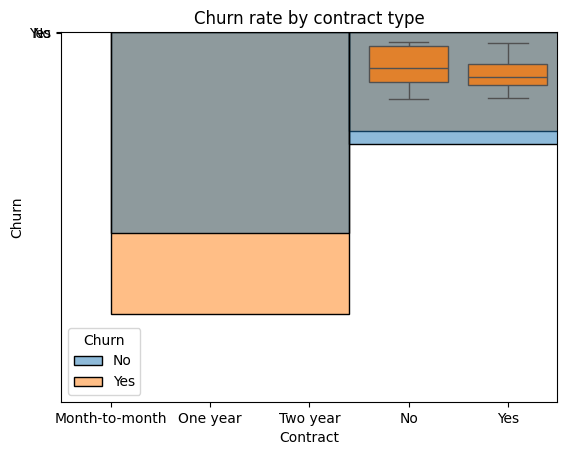

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn rate by contract type
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn rate by contract type')

# Tenure distribution by churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)

# Monthly charges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

Text(0.5, 1.0, 'Feature correlations')

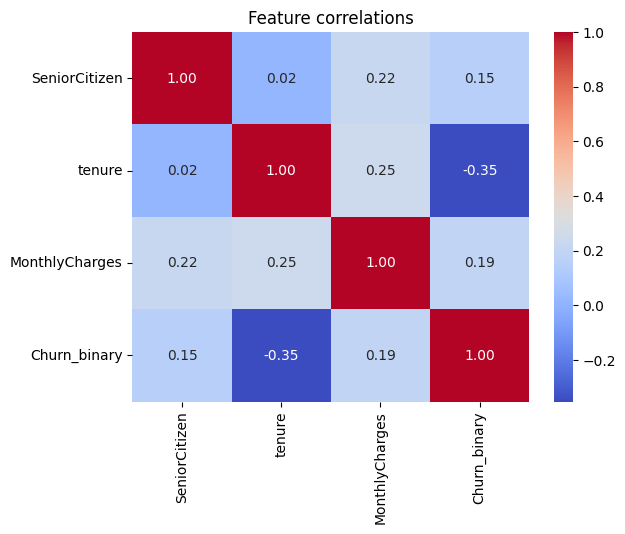

In [15]:
import numpy as np

# Encode Churn as binary first
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Only numeric columns
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations')

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# Encode binary columns
binary_cols = ['gender','Partner','Dependents','PhoneService',
               'PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# One-hot encode multi-category columns
df = pd.get_dummies(df, drop_first=True)

In [19]:
# Charges per month of tenure (value efficiency)
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Has multiple services flag
service_cols = ['PhoneService','OnlineSecurity_Yes','OnlineBackup_Yes',
                'DeviceProtection_Yes','TechSupport_Yes','StreamingTV_Yes']
df['num_services'] = df[service_cols].sum(axis=1)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)